In [1]:
# 6 strategies, used StraightForceToColony to see if results are different

# adding ApplyColonyPullingForce() to informed as 5 but more runs
# run on maze more time than 7 200 ants detchafter 4f to 10f 	float colonyPullStrength = 4.0f

#changes strategies 0  is always on 
#checking wich combination is the best
# Map 4 
# x3 amount of pheromones   public float dstBetweenMarkers = 0.75f; - > 0.2f

In [1]:
from sim_tools import run_simulation, SimulationParameters, run_simulations_batch, load_results_from_directory, SimulationData
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [2]:
num_sim = 350
steering_strategies = 6

In [3]:

batch = [
    SimulationParameters(usePheromoneSteering=i % steering_strategies)
    for i in range(steering_strategies * num_sim)
]
batch_results = run_simulations_batch(batch, "sim17_results", processes=5)
batch_results = list(zip(batch, batch_results)) 

Running simulations: 100%|██████████| 2100/2100 [38:51<00:00,  1.11s/it] 


In [4]:
batch_results = load_results_from_directory("sim17_results")

In [6]:
len(batch_results)

1516

In [5]:
Steering_names = [
    "home",
    "circle",
    "gradient",
    "gaussian",
    "Inverse Square",
    "Exponential",
]

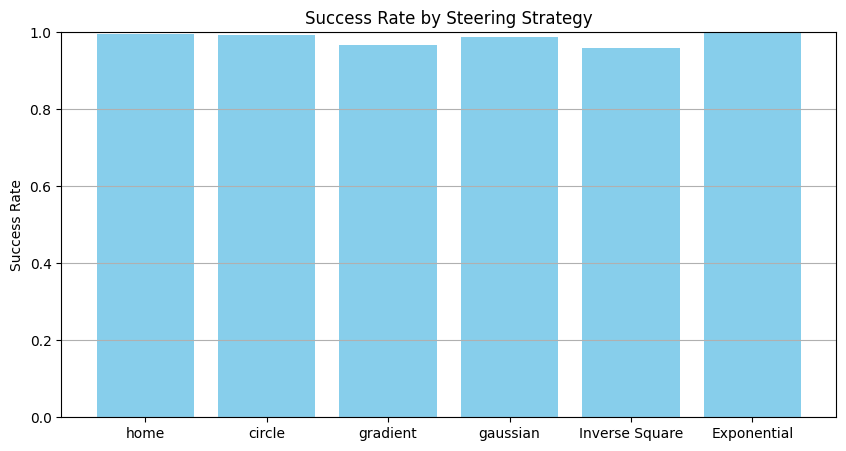

home: Success Rate=99.48% (380/382)
circle: Success Rate=99.21% (379/382)
gradient: Success Rate=96.60% (369/382)
gaussian: Success Rate=98.69% (377/382)
Inverse Square: Success Rate=95.81% (366/382)
Exponential: Success Rate=99.74% (380/381)


In [6]:
def plot_success_rates(batch_results: list[SimulationData], num_strategies=6, strategy_names=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for params, res in batch_results:
        strategy = params.usePheromoneSteering
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and res.didSucceed:
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), success_rates,
            tick_label=labels, color='skyblue')
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")



plot_success_rates(batch_results, steering_strategies, Steering_names)

In [7]:
print("Batch results:", len(batch_results))
len(batch_results)

Batch results: 2291


2291

In [8]:
# print results
def print_results(batch_results):
    for res, ss in batch_results:
        if res:
            print(
                f"Run (usePheromoneSteering={ss}): Success, duration={res.duration}, success={res.didSucceed}")
        else:
            print(f"Run (usePheromoneSteering={ss}): Failed")                      

In [9]:
import matplotlib.pyplot as plt


def plot_torus_positions_by_strategy(batch_results, strategy_names=None):
    """
    Plots the torus positions for each strategy in separate graphs.
    Each plot shows the paths for all successful runs of that strategy.
    """
    if strategy_names is None:
        strategy_names = [f"Steering={i}" for i in range(steering_strategies)]

    for strategy in range(steering_strategies):
        # Collect all successful torus positions for this strategy
        paths = [
            res.torusPositions for params, res in batch_results
            if params.usePheromoneSteering == strategy and res  and res.didSucceed
        ]
        if not paths:
            continue  # Skip if no successful runs

        plt.figure(figsize=(6, 6))
        for path in paths:
            xs = [p.x for p in path]
            ys = [p.y for p in path]
            plt.plot(xs, ys, alpha=0.5)
        plt.title(f"Torus Paths - {strategy_names[strategy]}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.axis("equal")
        plt.show()

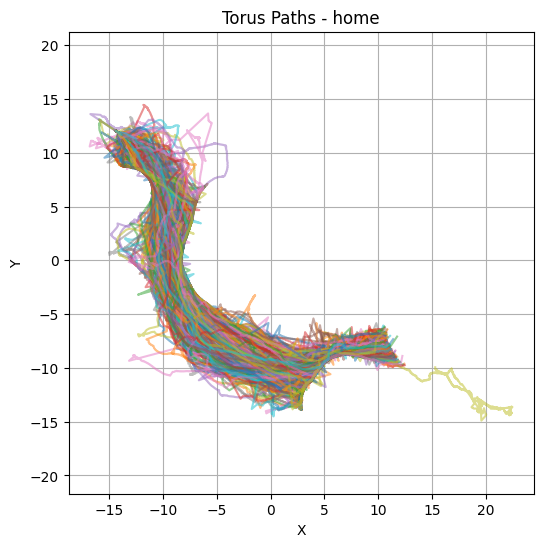

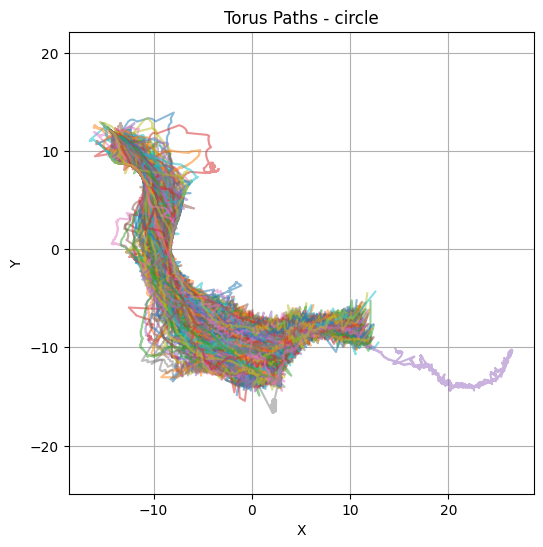

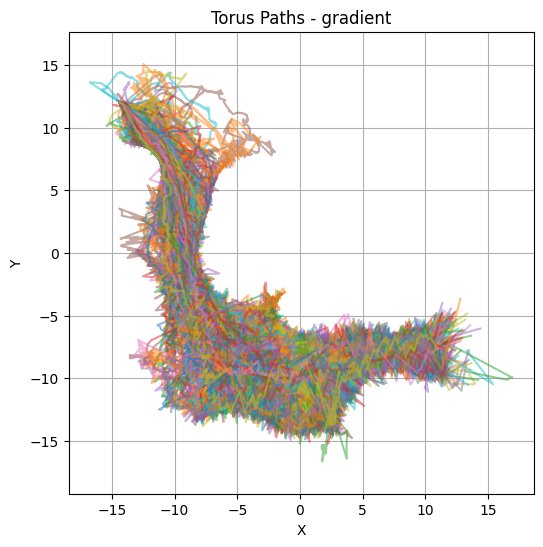

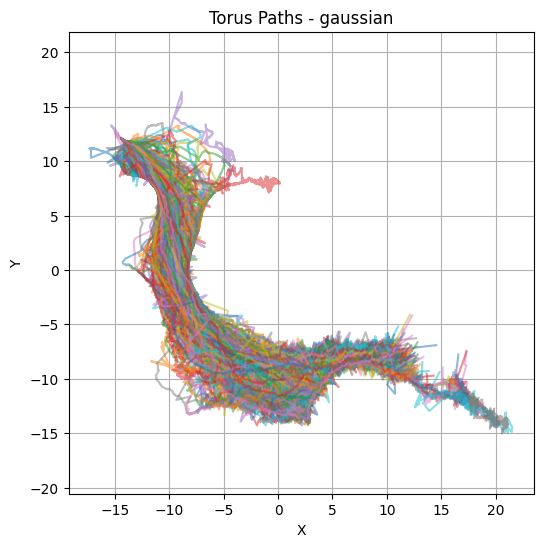

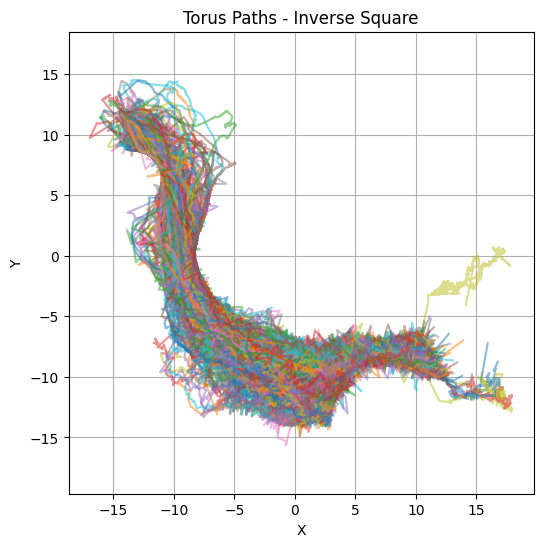

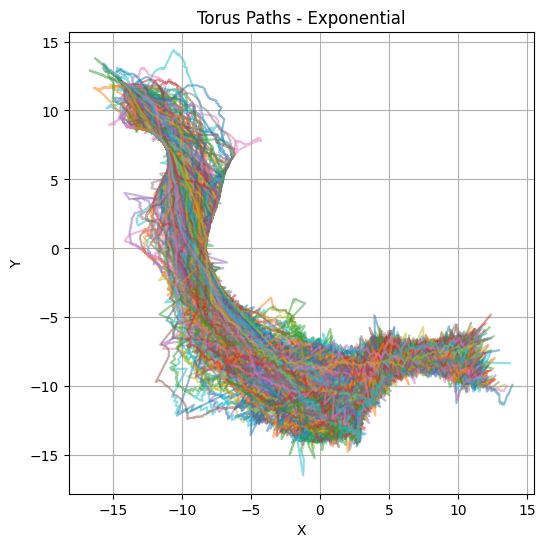

In [10]:
plot_torus_positions_by_strategy(batch_results, Steering_names)

In [11]:
import matplotlib.pyplot as plt
import numpy as np


def plot_duration_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the durations (time to win) for each strategy.
    Only successful runs are included.
    """

    # Collect durations for each strategy
    durations_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and res.didSucceed == True:
            durations_by_strategy[params.usePheromoneSteering].append(res.duration)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(steering_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(durations_by_strategy, tick_labels=labels)
    plt.ylabel("Duration (seconds)")
    plt.title("Time to Win by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average duration for each strategy
    for i in range(steering_strategies):
        avg = np.mean(
            durations_by_strategy[i]) if durations_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Duration = {avg:.2f} seconds")

# Example usage:

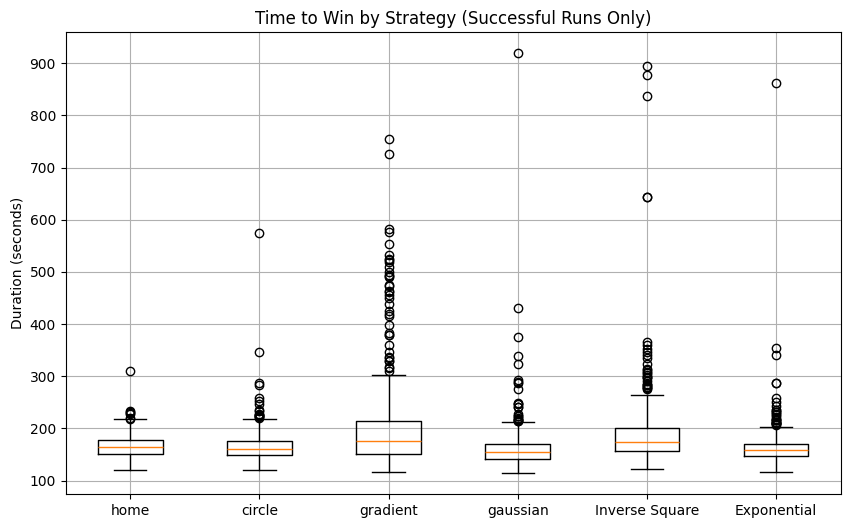

home: Average Duration = 165.61 seconds
circle: Average Duration = 167.26 seconds
gradient: Average Duration = 206.54 seconds
gaussian: Average Duration = 163.65 seconds
Inverse Square: Average Duration = 192.51 seconds
Exponential: Average Duration = 165.43 seconds


In [12]:
plot_duration_comparison(batch_results, Steering_names)

In [13]:
import matplotlib.pyplot as plt
import numpy as np


def compute_path_length(points):
    """Compute total path length from a list of Point objects with x, y attributes."""
    if not points or len(points) < 2:
        return 0
    return sum(
        np.linalg.norm([points[i+1].x - points[i].x,
                       points[i+1].y - points[i].y])
        for i in range(len(points)-1)
    )


def plot_path_length_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the total path length for each strategy.
    Only successful runs are included.
    """

    # Collect path lengths for each strategy
    path_lengths_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and res.didSucceed and hasattr(res, "torusPositions"):
            path_length = compute_path_length(res.torusPositions)
            path_lengths_by_strategy[params.usePheromoneSteering].append(path_length)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(steering_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(path_lengths_by_strategy, tick_labels=labels)
    plt.ylabel("Total Path Length")
    plt.title("Torus Path Length by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average path length for each strategy
    for i in range(steering_strategies):
        avg = np.mean(
            path_lengths_by_strategy[i]) if path_lengths_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Path Length = {avg:.2f}")

# Example usage:

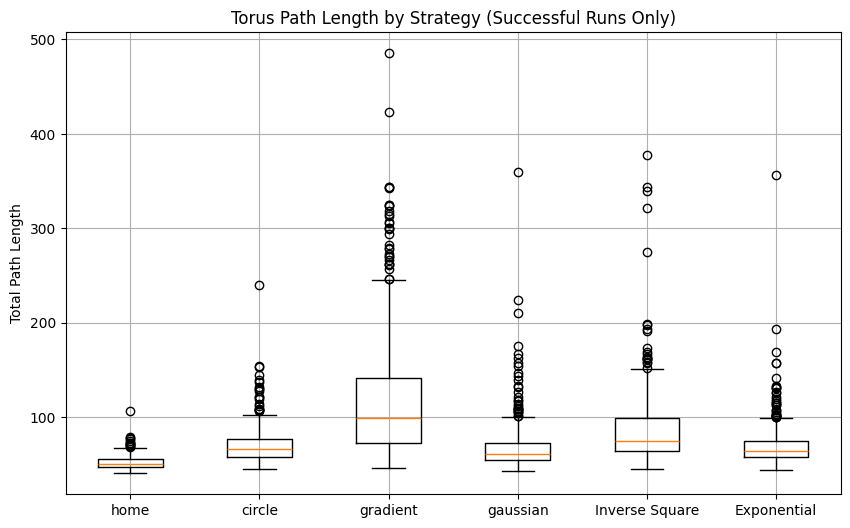

home: Average Path Length = 52.43
circle: Average Path Length = 70.57
gradient: Average Path Length = 121.15
gaussian: Average Path Length = 69.26
Inverse Square: Average Path Length = 88.03
Exponential: Average Path Length = 70.57


In [14]:
plot_path_length_comparison(batch_results, Steering_names)

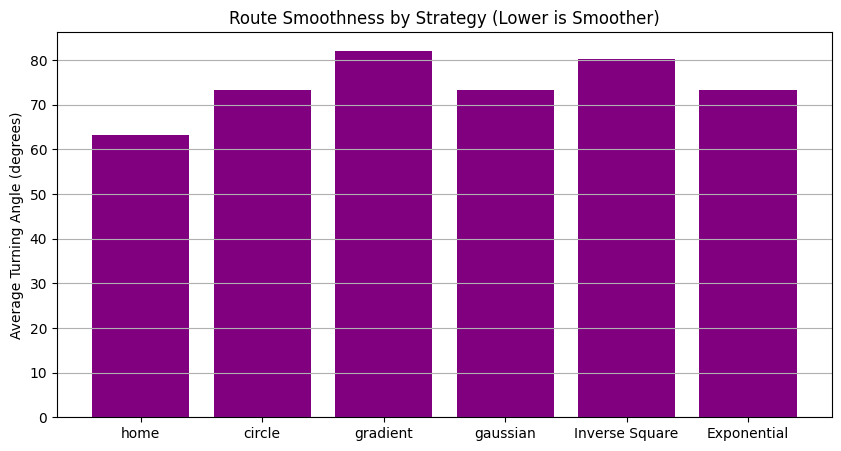

home: Average Turning Angle = 63.18°
circle: Average Turning Angle = 73.29°
gradient: Average Turning Angle = 82.11°
gaussian: Average Turning Angle = 73.31°
Inverse Square: Average Turning Angle = 80.26°
Exponential: Average Turning Angle = 73.24°


C:\Users\matanco\AppData\Local\Temp\ipykernel_41796\3801763716.py:103: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


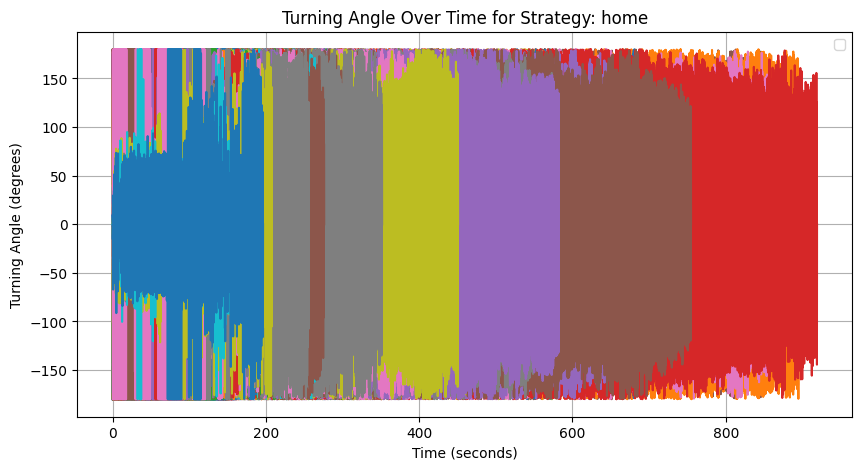

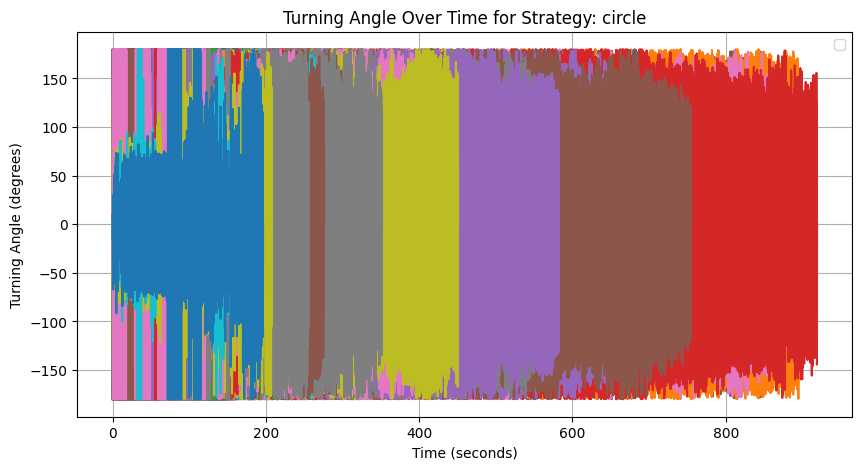

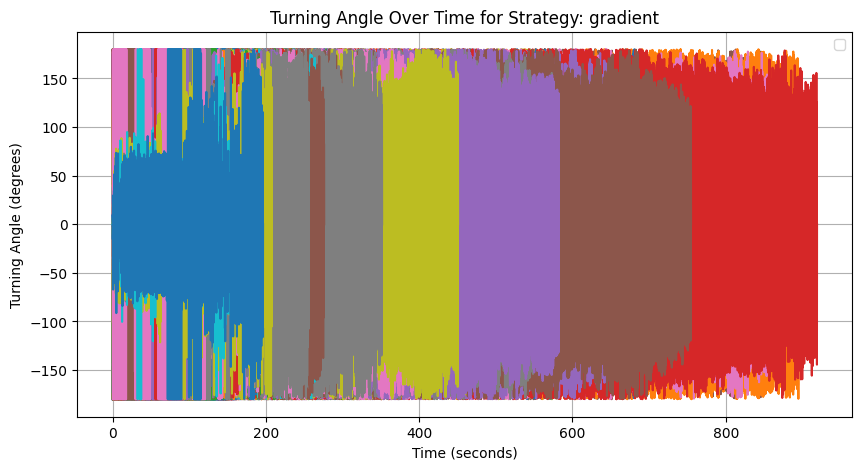

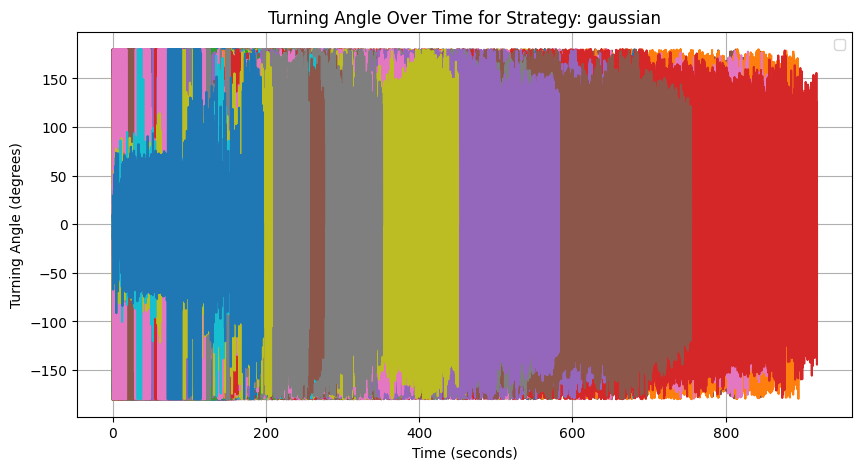

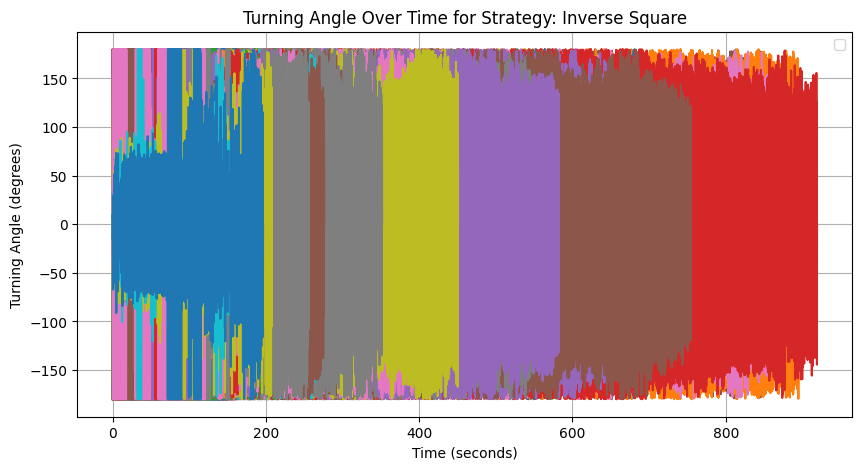

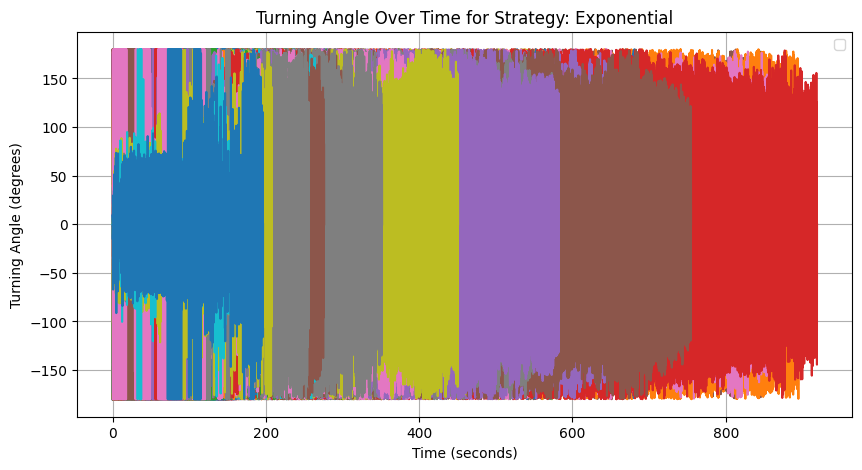

In [15]:
import numpy as np
import matplotlib.pyplot as plt


def compute_turning_angles(points):
    """Compute average signed turning angle (in degrees) between consecutive segments of a path."""
    if len(points) < 3:
        return 0.0

    # Extract coordinates as arrays
    coords = np.array([[p.x, p.y] for p in points])

    # Compute vectors between consecutive points
    v1 = coords[1:-1] - coords[:-2]  # Segment before
    v2 = coords[2:] - coords[1:-1]   # Segment after

    # Normalize to avoid division by zero
    norms1 = np.linalg.norm(v1, axis=1)
    norms2 = np.linalg.norm(v2, axis=1)
    valid = (norms1 > 1e-8) & (norms2 > 1e-8)

    v1 = v1[valid]
    v2 = v2[valid]

    # Compute signed angles using arctangent of cross and dot product
    cross = v1[:, 0]*v2[:, 1] - v1[:, 1]*v2[:, 0]  # 2D cross product
    dot = np.einsum('ij,ij->i', v1, v2)

    angles = np.arctan2(cross, dot)  # signed turning angle in radians
    return angles * (180.0 / np.pi)  # convert to degrees

# np.degrees(np.mean(np.abs(angles))) if len(angles) > 0 else 0.0

def compute_average_turning_angle(torus_positions):
    """
    Computes the average turning angle (smoothness) of the path defined by torus positions.
    Returns the average angle in degrees.
    """
    if not torus_positions or len(torus_positions) < 3:
        return 0.0  # Not enough points to compute angles
    
    angles = compute_turning_angles(torus_positions)
    return np.mean(np.abs(angles)) if len(angles) > 0 else 0.0  # Average of absolute angles

def plot_smoothness_comparison(batch_results, strategy_names=None):
    """
    Plots a bar chart comparing the average turning angle (smoothness) for each strategy.
    Only successful runs are included.
    """
    smoothness_by_strategy = [[] for _ in range(steering_strategies)]
    for params, res in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            avg_angle = compute_average_turning_angle(res.torusPositions)
            smoothness_by_strategy[params.usePheromoneSteering].append(avg_angle)

    # Compute mean smoothness for each strategy
    mean_smoothness = [
        np.mean(smoothness_by_strategy[i]) if smoothness_by_strategy[i] else float(
            'nan')
        for i in range(steering_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(steering_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(steering_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(steering_strategies), mean_smoothness,
            tick_label=labels, color='purple')
    plt.ylabel("Average Turning Angle (degrees)")
    plt.title("Route Smoothness by Strategy (Lower is Smoother)")
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(steering_strategies):
        print(
            f"{labels[i]}: Average Turning Angle = {mean_smoothness[i]:.2f}°")
        
    # add plot for angle over time
def plot_angle_over_time(batch_results, strategy_names=None):
    """ Plots the average turning angle over time for each strategy.  
    Only successful runs are included.
    """
    #angles_by_strategy = [[] for _ in range(steering_strategies)]
    #time_by_strategy = [[] for _ in range(steering_strategies)]
    
    for i in range(steering_strategies):
        # Collect angles and time for each strategy
        plt.figure(figsize=(10, 5))
        for params, res in batch_results:
            if res and res.didSucceed == True and hasattr(res, "torusPositions"):
                angles = compute_turning_angles(res.torusPositions)
                time = np.linspace(0, res.duration, len(angles))
                plt.plot(time, angles)
        plt.xlabel("Time (seconds)")
        plt.ylabel("Turning Angle (degrees)")
        plt.title(f"Turning Angle Over Time for Strategy: {strategy_names[i]}")
        plt.legend()
        plt.grid()
        plt.show()

# Example usage:
plot_smoothness_comparison(batch_results, Steering_names)
plot_angle_over_time(batch_results, Steering_names)